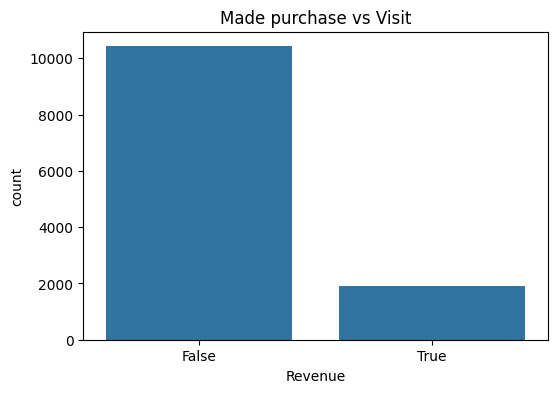

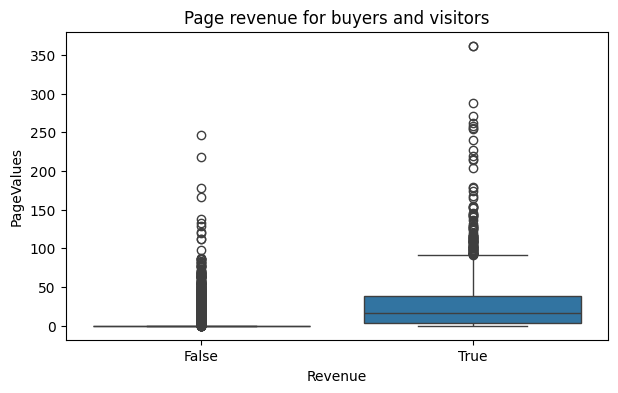

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('datasets/online_shoppers_intention.csv')

plt.figure(figsize=(6,4))
sns.countplot(x='Revenue', data=df)
plt.title('Made purchase vs Visit')
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title('Page revenue for buyers and visitors')
plt.show()

In [2]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score


X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int) 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=30, stratify=y)

cat_features = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']


model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced', 
    eval_metric='AUC',
    verbose=100
)

model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test), early_stopping_rounds=100)

0:	test: 0.9083179	best: 0.9083179 (0)	total: 65.5ms	remaining: 1m 5s
100:	test: 0.9358852	best: 0.9359468 (98)	total: 622ms	remaining: 5.54s
200:	test: 0.9371250	best: 0.9372105 (168)	total: 1.32s	remaining: 5.24s
300:	test: 0.9383221	best: 0.9383221 (300)	total: 2.09s	remaining: 4.86s
400:	test: 0.9402792	best: 0.9402792 (400)	total: 2.91s	remaining: 4.35s
500:	test: 0.9403697	best: 0.9404777 (434)	total: 3.76s	remaining: 3.74s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9404776859
bestIteration = 434

Shrink model to first 435 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.03, verbose=100)

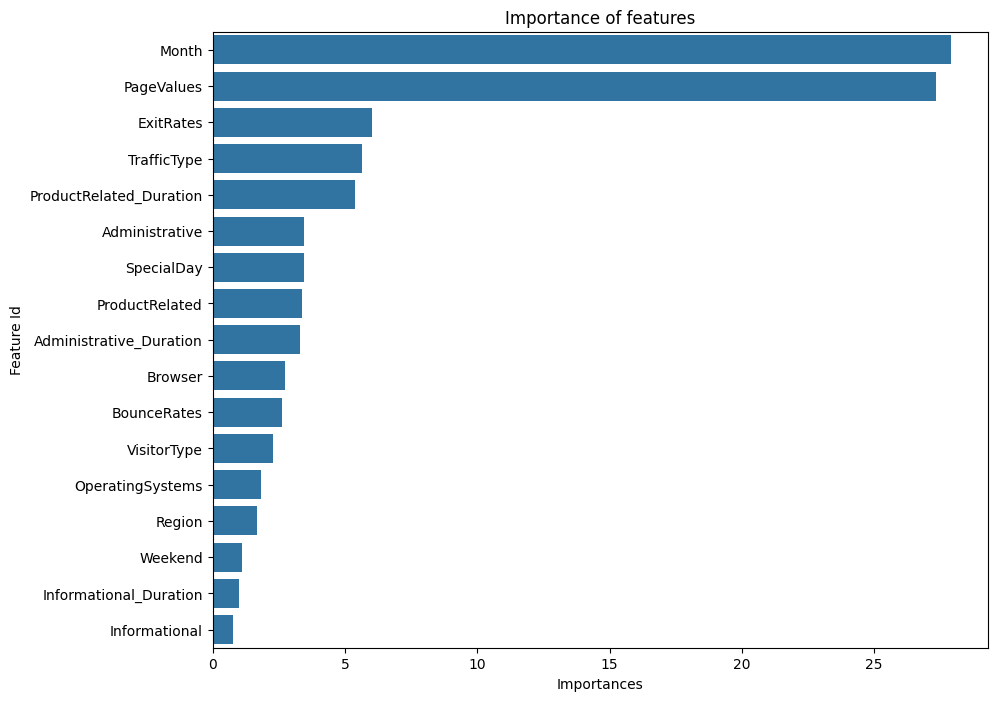

In [3]:
fi = model.get_feature_importance(prettified=True)

plt.figure(figsize=(10, 8))
sns.barplot(x="Importances", y="Feature Id", data=fi)
plt.title('Importance of features')
plt.show()

In [4]:
model.save_model('ecom_model.cbm')